# 03 · Ensembles & fusion on the hexacopter sequence

The point of the project is not any single backend but **combining** them. The
six baselines from notebook 02 become inputs to the ensemble/fusion layer, which
ships four modes:

| Fusion mode | Mechanism |
| --- | --- |
| `confidence_weighted` | per-step convex blend by static reliability × confidence × health |
| `weighted_ekf` | error-state EKF over IMU; each backend offers gated absolute-position updates |
| `winner_takes_healthy` | follow the single healthiest backend, switching with hysteresis |
| `rl_gated` *(learned)* | a PPO policy sets per-backend **trust** each control period (needs a trained checkpoint) |

We reuse the exact fusion functions the CLI calls, so results match
`python -m nav_benchmark run --method ensemble --fusion …`.

In [1]:
# --- Notebook bootstrap: put the src/ package on the path, pick the dataset ---
import sys, time, warnings
from pathlib import Path

# Find the repo root (the folder that holds pyproject.toml) starting from the
# notebook's working directory, so this runs whether the kernel starts in
# notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")  # hide benign divide-by-zero notices from the baselines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 92

# The "hexacopter" part of MVSEC is the indoor_flying sequences (a DAVIS346
# event camera + IMU + grayscale rig flown on a hexacopter with motion-capture
# ground truth). We use a pre-converted 15 s slice (5 s -> 20 s) of
# indoor_flying1. Prefer the image-inclusive slice; fall back to events+IMU.
DATA = ROOT / "data"
CANDIDATES = ["indoor_flying1_5s20s_img.h5", "indoor_flying1_5s20s.h5"]
SEQ_PATH = next((DATA / c for c in CANDIDATES if (DATA / c).exists()), None)
assert SEQ_PATH is not None, (
    "No hexacopter slice found under data/. Regenerate one (needs the MVSEC bags) with:\n"
    "  uv run python scripts/convert_mvsec_bag_to_h5.py \\\n"
    "    --data-bag data/indoor_flying1_data.bag --gt-bag data/indoor_flying1_gt.bag \\\n"
    "    --output data/indoor_flying1_5s20s_img.h5 --start-sec 5 --duration-sec 15 --include-images"
)
print("Repo root :", ROOT)
print("Sequence  :", SEQ_PATH.name)

Repo root : /home/jovyan/event-based-vio
Sequence  : indoor_flying1_5s20s_img.h5


In [2]:
import types
from collections import Counter
from nav_benchmark.datasets.mvsec import load_mvsec_sequence
from nav_benchmark.events.representations import ensure_event_frames
from nav_benchmark.run import _imu_only_config_for_sequence, _ensemble_baselines
from nav_benchmark.ensemble.confidence_weighted import (
    fuse_trajectories, EnsembleConfig, ENSEMBLE_WEIGHT_COLUMNS,
)
from nav_benchmark.ensemble.ekf import EkfConfig
from nav_benchmark.ensemble.fusion import (
    run_weighted_ekf_fusion, EkfFusionConfig,
    run_winner_takes_healthy, WinnerTakesHealthyConfig,
)
from nav_benchmark.evaluation.harness import load_ground_truth_trajectory
from nav_benchmark.evaluation.metrics import evaluate_trajectory, EvalConfig

# nav_benchmark.evaluation.plots forces a headless Agg backend at import time
# (great for the CLI, but it silently disables inline figures). Re-assert the
# inline backend now that those modules are imported, so plots render here.
get_ipython().run_line_magic("matplotlib", "inline")

seq = load_mvsec_sequence(SEQ_PATH)
ensure_event_frames(seq, window_sec=0.05)
args = types.SimpleNamespace(dataset="mvsec", input=str(SEQ_PATH),
                             sequence="indoor_flying1", event_window_ms=50.0)
imu_cfg = _imu_only_config_for_sequence(args, seq)
gt = load_ground_truth_trajectory(SEQ_PATH)
cfg = EvalConfig()

t0 = time.perf_counter()
baselines, _ = _ensemble_baselines(args, seq, None, imu_cfg)   # the 6 ensemble inputs
print(f"Prepared {len(baselines)} backend inputs in {time.perf_counter()-t0:.1f} s")

def score(traj):
    m = evaluate_trajectory(traj, gt, cfg).metrics
    return dict(ATE_rmse_m=round(m.ate_rmse, 3), RPE_rmse_m=round(m.rpe_rmse, 3),
               final_drift_m=round(m.final_drift, 2),
               drift_pct=None if m.drift_percent is None else round(m.drift_percent, 1))

Prepared 6 backend inputs in 32.8 s


## 1 · Confidence-weighted fusion

A per-timestep convex blend: each backend's weight is
`static_reliability × confidence × health_multiplier`, normalized across
backends. The stacked plot shows how weight shifts between backends over time.

confidence_weighted: {'ATE_rmse_m': 168.084, 'RPE_rmse_m': 0.92, 'final_drift_m': 1428.08, 'drift_pct': 41.6}


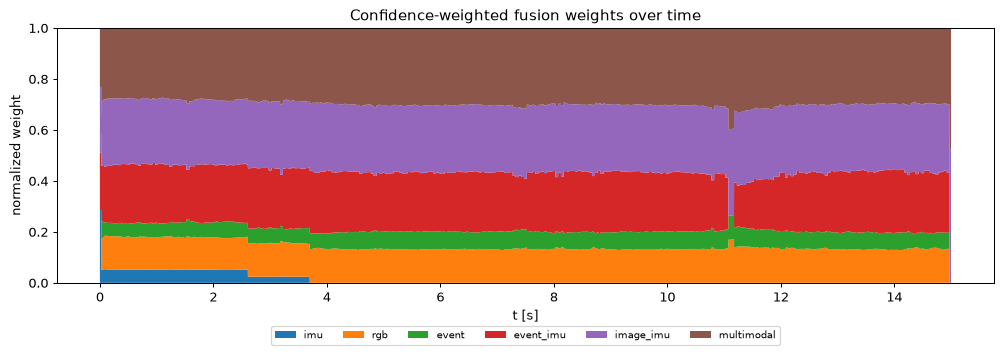

In [3]:
cw = fuse_trajectories(baselines, config=EnsembleConfig())
print("confidence_weighted:", score(cw))

t_rel = cw.timestamps - cw.timestamps[0]
labels = list(ENSEMBLE_WEIGHT_COLUMNS.values())         # w_imu, w_rgb, ...
W = np.vstack([cw.extra_columns[c] for c in labels])
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(t_rel, W, labels=[c.replace("w_", "") for c in labels])
ax.set_title("Confidence-weighted fusion weights over time")
ax.set_xlabel("t [s]"); ax.set_ylabel("normalized weight"); ax.set_ylim(0, 1)
ax.legend(ncol=6, loc="upper center", fontsize=8, bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(); plt.show()

## 2 · Weighted error-state EKF (gated)

An error-state EKF propagates the raw IMU; each backend pose is offered as an
absolute-position update and passes through a stack of gates (health,
confidence, timestamp age, motion-sanity, Mahalanobis χ²). **Most candidate
updates are rejected** — that gating is the safety mechanism.

weighted_ekf: {'ATE_rmse_m': 141.302, 'RPE_rmse_m': 0.988, 'final_drift_m': 1479.75, 'drift_pct': 92.9}
45,800 candidate updates -> 509 accepted (1.1%)


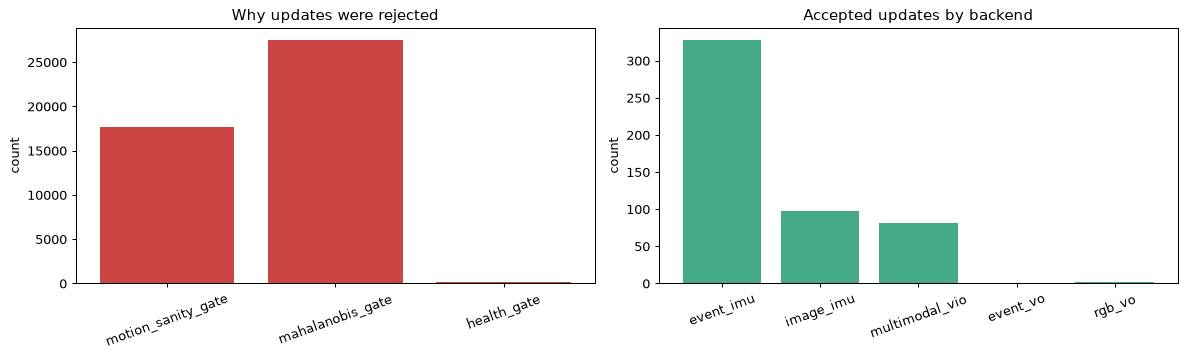

In [4]:
measurements = {m: t for m, t in baselines.items() if m != "imu_only"}
ekf_cfg = EkfFusionConfig(ekf=EkfConfig(gravity=imu_cfg.gravity))
ekf_traj, records = run_weighted_ekf_fusion(
    seq.imu, measurements, config=ekf_cfg,
    initial_position=imu_cfg.initial_position,
    initial_velocity=imu_cfg.initial_velocity,
    initial_orientation_xyzw=imu_cfg.initial_orientation,
)
print("weighted_ekf:", score(ekf_traj))
accepted = [r for r in records if r.accepted]
print(f"{len(records):,} candidate updates -> {len(accepted):,} accepted "
      f"({100*len(accepted)/len(records):.1f}%)")

reject_reasons = Counter(r.reason for r in records if not r.accepted)
accept_by_method = Counter(r.method for r in accepted)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
a0.bar(list(reject_reasons), list(reject_reasons.values()), color="#c44")
a0.set_title("Why updates were rejected"); a0.set_ylabel("count"); a0.tick_params(axis="x", rotation=20)
a1.bar(list(accept_by_method), list(accept_by_method.values()), color="#4a8")
a1.set_title("Accepted updates by backend"); a1.set_ylabel("count"); a1.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 3 · Winner-takes-healthy

Instead of blending, this mode follows the single healthiest backend at each
step, switching only when a challenger clearly wins (hysteresis). The step plot
shows which backend is "driving" over time.

winner_takes_healthy: {'ATE_rmse_m': 89.05, 'RPE_rmse_m': 0.806, 'final_drift_m': 1548.34, 'drift_pct': 36.0}


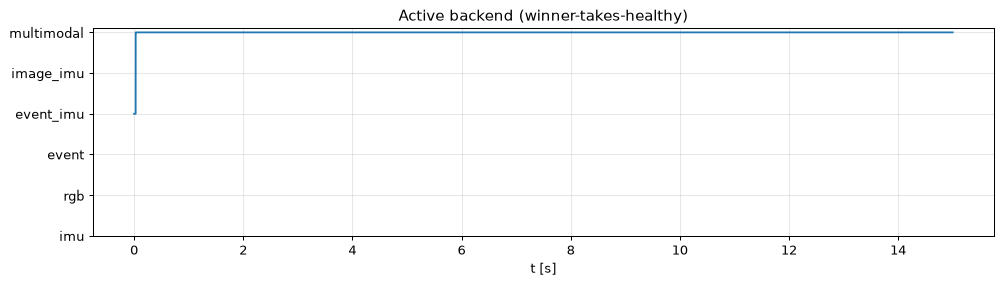

In [5]:
wth = run_winner_takes_healthy(baselines, config=WinnerTakesHealthyConfig())
print("winner_takes_healthy:", score(wth))

cols = list(ENSEMBLE_WEIGHT_COLUMNS.values())
names = [c.replace("w_", "") for c in cols]
Wmat = np.vstack([wth.extra_columns[c] for c in cols])
active = np.argmax(Wmat, axis=0)      # exactly one weight is 1.0 per step
t_rel = wth.timestamps - wth.timestamps[0]
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.step(t_rel, active, where="post", lw=1.4)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("t [s]"); ax.set_title("Active backend (winner-takes-healthy)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Head-to-head: ensembles vs. their inputs

Comparison table and an overlay of ground truth, the best single baseline, and
the three deterministic ensembles (all SE(3)-aligned).

,ATE_rmse_m,RPE_rmse_m,final_drift_m,drift_pct
imu_only (input),28.655,0.989,67.95,68.0
rgb_vo (best input),0.385,1.236,0.43,6.5
confidence_weighted,168.084,0.920,1428.08,41.6
weighted_ekf,141.302,0.988,1479.75,92.9
winner_takes_healthy,89.050,0.806,1548.34,36.0


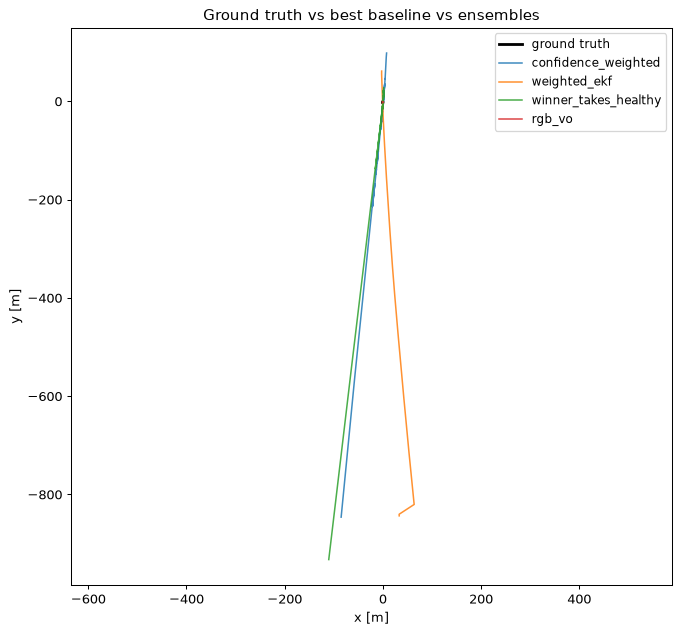

In [6]:
# Best single baseline by ATE (for a fair "did fusion help?" comparison).
base_scores = {name: score(traj) for name, traj in baselines.items()}
best_base = min(base_scores, key=lambda n: base_scores[n]["ATE_rmse_m"])

table = pd.DataFrame({
    f"imu_only (input)": base_scores["imu_only"],
    f"{best_base} (best input)": base_scores[best_base],
    "confidence_weighted": score(cw),
    "weighted_ekf": score(ekf_traj),
    "winner_takes_healthy": score(wth),
}).T
display(table)

overlay = {
    "confidence_weighted": cw,
    "weighted_ekf": ekf_traj,
    "winner_takes_healthy": wth,
    f"{best_base}": baselines[best_base],
}
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.plot(gt.positions[:, 0], gt.positions[:, 1], "k-", lw=2.2, label="ground truth")
for name, traj in overlay.items():
    est = evaluate_trajectory(traj, gt, cfg).aligned_estimate.positions
    ax.plot(est[:, 0], est[:, 1], lw=1.2, alpha=0.85, label=name)
ax.axis("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("Ground truth vs best baseline vs ensembles"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4 · The learned RL-gated ensemble

`--fusion rl_gated` keeps the same error-state EKF but replaces the fixed gate
trust with a **PPO policy** that outputs a per-backend trust ∈ [0, 1] each
control period (optionally informed by JEPA perception signals). Key properties:

- **Safety-preserving:** the hard gates (health / confidence / timestamp /
  motion / χ²) can never be bypassed by the policy.
- **Parity invariant:** with trust ≡ 1 it reproduces `weighted_ekf` bit-for-bit.
- It targets the case static weighting can't solve — a backend that **drifts
  while still reporting high confidence** — which needs perturbed training data.

Running it needs a trained checkpoint. Training campaigns (MVSEC windows, GPU)
are deferred, so this cell only *shows the commands*; it looks for a policy and
reports gracefully if none is present rather than erroring.

In [7]:
policies = sorted(ROOT.glob("**/*.pt"))
print("Trained policy checkpoints found:", [str(p.relative_to(ROOT)) for p in policies] or "none")
print(r"""
# --- Train, then run the learned ensemble (see docs/rl-ensemble.md) ---
# 1) optional self-supervised JEPA perception model
uv run python -m nav_benchmark train-jepa --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output runs/jepa.pt

# 2) train the PPO trust-gating policy (needs GT-bearing inputs)
uv run python -m nav_benchmark train-rl --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output-dir runs/rl --jepa runs/jepa.pt

# 3) run the ensemble with the learned policy
uv run python -m nav_benchmark run --method ensemble --fusion rl_gated \
    --dataset mvsec --sequence indoor_flying1 \
    --input data/indoor_flying1_5s20s_img.h5 \
    --policy runs/rl/policy.pt --jepa runs/jepa.pt --evaluate
""")

if policies:
    from nav_benchmark.rl.ppo import PpoAgent
    from nav_benchmark.rl.runner import restore_policy_configs, run_rl_gated_fusion
    from nav_benchmark.ensemble.rl_gated import RlGatedFusionConfig
    agent = PpoAgent.load(str(policies[0]))
    _feat, control_period, min_trust = restore_policy_configs(agent)
    rl_cfg = RlGatedFusionConfig(base=ekf_cfg, control_period_sec=control_period, min_trust_to_apply=min_trust)
    rl_traj, rl_records, _trust = run_rl_gated_fusion(
        seq.imu, measurements, agent, fusion_config=rl_cfg,
        initial_position=imu_cfg.initial_position,
        initial_velocity=imu_cfg.initial_velocity,
        initial_orientation_xyzw=imu_cfg.initial_orientation, jepa_series=None,
    )
    print("rl_gated:", score(rl_traj))
else:
    print("\n(No checkpoint present — skipping the live rl_gated run.)")

Trained policy checkpoints found: none

# --- Train, then run the learned ensemble (see docs/rl-ensemble.md) ---
# 1) optional self-supervised JEPA perception model
uv run python -m nav_benchmark train-jepa --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output runs/jepa.pt

# 2) train the PPO trust-gating policy (needs GT-bearing inputs)
uv run python -m nav_benchmark train-rl --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output-dir runs/rl --jepa runs/jepa.pt

# 3) run the ensemble with the learned policy
uv run python -m nav_benchmark run --method ensemble --fusion rl_gated \
    --dataset mvsec --sequence indoor_flying1 \
    --input data/indoor_flying1_5s20s_img.h5 \
    --policy runs/rl/policy.pt --jepa runs/jepa.pt --evaluate


(No checkpoint present — skipping the live rl_gated run.)


## Takeaways

- The fusion layer turns six imperfect backends into one trajectory via three
  deterministic strategies (blend / gated-EKF / switch) plus a learned policy.
- On this **clean 15 s slice**, arbitration does **not** beat the best single
  baseline — the GT-scaled feature VO is hard to top, and the honest table above
  says so. The EKF's value shows in its **gating**: it rejects the large majority
  of bad candidate updates instead of letting them corrupt the state.
- Ensemble benefit is largest under **sensor dropout / degraded backends** — the
  regime the perturbation-trained `rl_gated` policy is built for. That's the next
  step once training runs on GPU (`docs/rl-ensemble.md`).